## Symulator tomografu komputerowego

In [1]:
from skimage import io, color
import matplotlib.pyplot as plt
import numpy as np

#### Wczytywanie obrazu

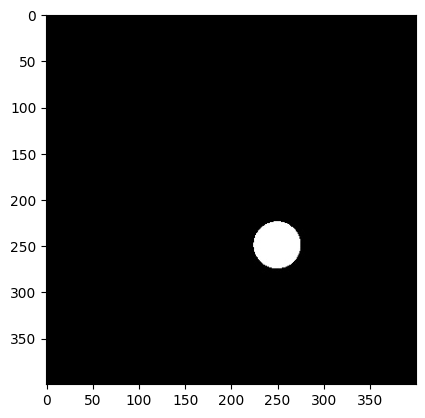

In [3]:
img = io.imread("img/Kropka.jpg")

if len(img.shape) == 3:
    img = color.rgb2gray(img)

plt.imshow(img, cmap='gray')
plt.show()

#### Transformata Radona (tworzenie sinogramu)

In [4]:
def sample_line(x0, y0, x1, y1):
    h, w = img.shape
    
    xs = np.linspace(x0, x1, num_samples)
    ys = np.linspace(y0, y1, num_samples)
    
    values = []
    
    for x, y in zip(xs, ys):
        ix = int(round(x))
        iy = int(round(y))
        
        if 0 <= ix < w and 0 <= iy < h:
            values.append(img[iy, ix])
    
    return np.sum(values)

In [5]:
def radon_transformation():
    h, w = img.shape
    cx, cy = w // 2, h // 2
    r = np.sqrt(cx**2 + cy**2)

    phi = np.pi / 2
    angles = np.deg2rad(np.arange(0, 360, alpha))

    sinogram = []

    for a in angles:
        projections = []

        xE = cx + r * np.cos(a)
        yE = cy - r * np.sin(a)

        for i in range(n):
            if i == 0:
                xD = cx + r * np.cos(a + np.pi - (phi / 2))
                yD = cy - r * np.sin(a + np.pi - (phi / 2))
            else:
                xD = cx + r * np.cos(a + np.pi - (phi / 2) + i * (phi / (n - 1)))
                yD = cy - r * np.sin(a + np.pi - (phi / 2) + i * (phi / (n - 1)))

            val = sample_line(xE, yE, xD, yD)
            projections.append(val)

        sinogram.append(projections)
    
    return np.array(sinogram)

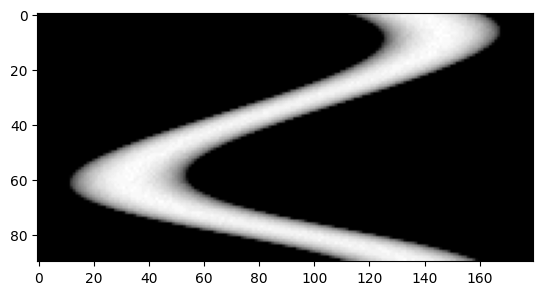

In [6]:
n = 180                 # liczba detektorów
l = 1                   # rozpiętość detektorów
alpha = 4               # krok układu
num_samples = 500       # liczba próbek dla linii

sinogram = radon_transformation()

plt.imshow(sinogram, cmap='gray')

#### Filtrowanie sinogramu

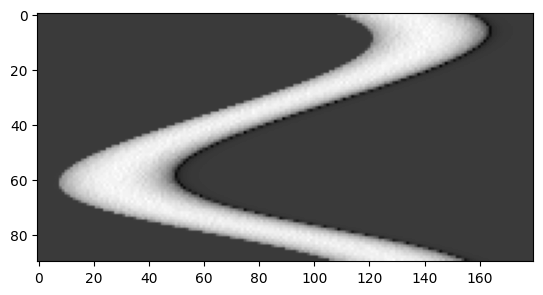

In [ ]:
def filter():
    filtered_sinogram = []
    kernel = []

    for k in range(21):
        if k == 0:
            kernel.append(1)
        elif k % 2 == 0:
            kernel.append(0)
        else:
            kernel.append((-4 / (np.pi**2)) / k**2)

    kernel = kernel[0:len(kernel) // 2]

    for i in range(len(sinogram)):
        filtered_sinogram.append(np.convolve(sinogram[i, :], kernel, mode='same'))
    
    return filtered_sinogram

plt.imshow(filter(), cmap='gray')

#### Odwrotna transformata Radona (rekonstrukcja obrazu)